# EDA 15 - Customer Acquisition Analysis

This notebook analyzes customer acquisition channels, customer quality by channel, revenue by channel, and leakage-safe acquisition forecast features using `customers.csv`, `orders.csv`, and `order_items.csv`.

## 1. Setup and file discovery

Locate the required CSV files recursively from the current working directory and configure shared display and plotting settings. No EDA outputs are saved to external files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 260)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
REQUIRED_FILES = ["customers.csv", "orders.csv", "order_items.csv"]
TOP_N_CHANNELS = 10

warning_messages = []
loaded_files = {}
file_paths = {}
analysis_ready = False
used_signup_proxy = False
used_item_revenue = False

customer_order_revenue = pd.DataFrame()
customer_level = pd.DataFrame()
customers_by_channel = pd.DataFrame()
orders_per_customer_by_channel = pd.DataFrame()
revenue_by_channel = pd.DataFrame()
quality_summary = pd.DataFrame()
monthly_acquisition = pd.DataFrame()
repeat_by_channel = pd.DataFrame()
feature_preview = pd.DataFrame()

channel_mix_statement = "Not evaluated."
top_customer_channels_text = "Not evaluated."
top_revenue_channels_text = "Not evaluated."
top_revenue_per_customer_text = "Not evaluated."
top_orders_per_customer_text = "Not evaluated."
top_repeat_channels_text = "Not evaluated."
forecast_warning = "Future customers and future channel mix must not be used directly for forecasting unless separately forecasted."
recommended_acquisition_features = [
    "daily_new_customers_lag",
    "new_customers_roll_mean_7",
    "new_customers_roll_mean_30",
    "repeat_customer_ratio_lag",
    "repeat_customer_ratio_roll_mean_30",
    "channel_mix_lag",
    "top_channel_share_lag",
    "channel_concentration_lag",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in REQUIRED_FILES:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": True,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in REQUIRED_FILES
])

missing_files = [filename for filename in REQUIRED_FILES if file_paths[filename] is None]
if missing_files:
    warning_messages.append("Required files not found: " + ", ".join(missing_files))

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,customers.csv,True,True,datathon-2026-round-1\customers.csv,1
1,orders.csv,True,True,datathon-2026-round-1\orders.csv,1
2,order_items.csv,True,True,datathon-2026-round-1\order_items.csv,1


## 2. Load customers, orders, and order_items

Load required files safely with pandas. If a required file is unavailable, the notebook displays a clear warning and skips dependent analysis.

In [2]:
load_rows = []
for filename in REQUIRED_FILES:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file not found"})
        continue
    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_rows.append({"file": filename, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        loaded_files[filename] = None
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in REQUIRED_FILES:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,loaded,rows,columns,error
0,customers.csv,True,121930,7,
1,orders.csv,True,646945,8,
2,order_items.csv,True,714669,7,


Preview: customers.csv


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


Preview: orders.csv


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


Preview: order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


## 3. Identify key, acquisition channel, date, and revenue columns

Infer customer/order keys, acquisition channel, signup date, order date, and order-item revenue fields. If direct revenue is unavailable, revenue is inferred as price times quantity minus discount.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    name_points = 0
    if name in {"date", "order_date", "signup_date", "created_at", "customer_created_date", "registration_date", "timestamp"}:
        name_points += 5
    elif "date" in name_tokens or "date" in name or "timestamp" in name or "time" in name:
        name_points += 3
    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {"column": column_name, "date_score": -5.0, "date_parse_success": 0.0, "plausible_date_share": 0.0}
    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parse_success = float(parsed[mask].notna().mean()) if non_empty else 0.0
    parsed_valid = parsed[mask].dropna()
    if len(parsed_valid):
        plausible_share = float(parsed_valid.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31")).mean())
        unique_dates = int(parsed_valid.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0
    score = name_points + 3 * parse_success + 2 * plausible_share + min(unique_dates / 20, 1)
    return {"column": column_name, "date_score": round(score, 4), "date_parse_success": round(parse_success, 4), "plausible_date_share": round(plausible_share, 4)}


def choose_date_column(df, preferred_terms=None):
    preferred_terms = preferred_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        row = date_score(col, df[col])
        name = normalize_name(col)
        for term in preferred_terms:
            if term in name:
                row["date_score"] += 5
        rows.append(row)
    candidates = pd.DataFrame(rows).sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def string_key_values(series):
    return series.dropna().astype("string").str.strip()


def key_candidates(df, key_kind):
    if df is None or df.empty:
        return []
    candidates = []
    for col in df.columns:
        name = normalize_name(col)
        name_tokens = set(name.split("_"))
        score = 0
        if key_kind == "customer":
            if name in {"customer_id", "customerid", "client_id", "user_id"}:
                score += 8
            if "customer" in name_tokens or "customer" in name or "client" in name or "user" in name:
                score += 4
        elif key_kind == "order":
            if name in {"order_id", "orderid", "id_order"}:
                score += 8
            if "order" in name_tokens or "order" in name:
                score += 4
        elif key_kind == "product":
            if name in {"product_id", "productid", "sku", "item_id"}:
                score += 8
            if "product" in name_tokens or "product" in name or "sku" in name:
                score += 4
        if "id" in name_tokens or name.endswith("_id") or name == "id":
            score += 3
        if "date" in name or "time" in name:
            score -= 5
        if score > 0:
            candidates.append((col, score))
    if not candidates:
        for col in df.columns:
            if df[col].nunique(dropna=True) > 1:
                candidates.append((col, 0))
    return candidates


def choose_join_key(left_df, right_df, key_kind):
    rows = []
    for left_col, left_score in key_candidates(left_df, key_kind):
        left_values = set(string_key_values(left_df[left_col]).unique())
        for right_col, right_score in key_candidates(right_df, key_kind):
            right_values = set(string_key_values(right_df[right_col]).unique())
            overlap_rate = len(left_values & right_values) / max(1, len(left_values)) if left_values and right_values else 0.0
            score = left_score + right_score + 10 * overlap_rate
            rows.append({
                "left_column": left_col,
                "right_column": right_col,
                "key_kind": key_kind,
                "score": score,
                "left_unique": len(left_values),
                "right_unique": len(right_values),
                "left_unique_overlap_rate": overlap_rate,
            })
    candidates = pd.DataFrame(rows).sort_values(["score", "left_unique_overlap_rate"], ascending=False) if rows else pd.DataFrame()
    if candidates.empty:
        return None, None, candidates
    best = candidates.iloc[0]
    if best["left_unique_overlap_rate"] < 0.05 and best["score"] < 8:
        return None, None, candidates
    return best["left_column"], best["right_column"], candidates


def choose_channel_column(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = df[col]
        non_null = values.notna().sum()
        unique = values.nunique(dropna=True)
        unique_rate = unique / max(non_null, 1)
        score = 0
        if name in {"acquisition_channel", "channel", "source", "marketing_channel"}:
            score += 10
        if "acquisition" in name:
            score += 6
        if "channel" in name or "source" in name or "campaign" in name:
            score += 5
        if pd.api.types.is_object_dtype(values) or pd.api.types.is_string_dtype(values):
            score += 2
        if 2 <= unique <= 100:
            score += 2
        if unique_rate > 0.75:
            score -= 4
        if any(term in name for term in ["id", "date", "zip", "age", "gender"]):
            score -= 3
        rows.append({"column": col, "channel_score": score, "unique_values": unique, "unique_rate": unique_rate})
    candidates = pd.DataFrame(rows).sort_values(["channel_score", "unique_values"], ascending=[False, True])
    if candidates.empty or candidates.iloc[0]["channel_score"] <= 0:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


def choose_numeric_by_terms(df, positive_terms, negative_terms=None):
    negative_terms = negative_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = numeric_series(df[col])
        non_empty = max(int(non_empty_mask(df[col]).sum()), 1)
        numeric_success = values.notna().sum() / non_empty
        if numeric_success < 0.70:
            continue
        score = numeric_success
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 5
        if values.dropna().std(ddof=1) > 0:
            score += 1
        rows.append({"column": col, "score": score, "numeric_parse_success": numeric_success, "mean": values.mean(), "std": values.std(ddof=1)})
    candidates = pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()
    if candidates.empty or candidates.iloc[0]["score"] <= 1:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


customers = loaded_files.get("customers.csv")
orders = loaded_files.get("orders.csv")
order_items = loaded_files.get("order_items.csv")

if customers is None or orders is None or order_items is None:
    customer_id_orders_col = customer_id_customers_col = order_id_orders_col = order_id_items_col = None
    channel_col = signup_date_col = order_date_col = None
    quantity_col = price_col = discount_col = direct_revenue_col = None
    revenue_method = "not available"
    detection_summary_df = pd.DataFrame([{"warning": "One or more required files were not loaded."}])
else:
    customer_id_orders_col, customer_id_customers_col, customer_key_candidates_df = choose_join_key(orders, customers, "customer")
    order_id_items_col, order_id_orders_col, order_key_candidates_df = choose_join_key(order_items, orders, "order")
    product_id_items_col = key_candidates(order_items, "product")[0][0] if key_candidates(order_items, "product") else None
    channel_col, channel_candidates_df = choose_channel_column(customers)
    signup_date_col, signup_date_candidates_df = choose_date_column(customers, preferred_terms=["signup", "created", "registration", "join"])
    order_date_col, order_date_candidates_df = choose_date_column(orders, preferred_terms=["order"])

    quantity_col, quantity_candidates_df = choose_numeric_by_terms(order_items, ["quantity", "qty", "units"], ["price", "discount", "amount", "id"])
    price_col, price_candidates_df = choose_numeric_by_terms(order_items, ["unit_price", "price", "sales_price", "item_price"], ["discount", "quantity", "qty", "id"])
    discount_col, discount_candidates_df = choose_numeric_by_terms(order_items, ["discount"], ["id", "date"])
    direct_revenue_col, direct_revenue_candidates_df = choose_numeric_by_terms(
        order_items,
        ["revenue", "line_total", "item_total", "sales_amount", "net_sales", "subtotal", "line_subtotal", "total"],
        ["discount", "price", "cost", "cogs", "quantity", "qty", "id"],
    )
    if direct_revenue_col is not None and any(term in normalize_name(direct_revenue_col) for term in ["discount", "price", "cost", "cogs", "quantity", "qty", "id"]):
        direct_revenue_col = None

    if direct_revenue_col is not None:
        revenue_method = f"direct item revenue column: {direct_revenue_col}"
    elif quantity_col is not None and price_col is not None:
        revenue_method = f"inferred: {quantity_col} * {price_col} (unit price is post-discount)"
    else:
        revenue_method = "not available"

    detection_summary_df = pd.DataFrame([{
        "customer_id_in_orders": customer_id_orders_col,
        "customer_id_in_customers": customer_id_customers_col,
        "order_id_in_order_items": order_id_items_col,
        "order_id_in_orders": order_id_orders_col,
        "product_id_in_order_items": product_id_items_col,
        "acquisition_channel_column": channel_col,
        "customer_signup_date_column": signup_date_col,
        "order_date_column": order_date_col,
        "direct_revenue_column": direct_revenue_col,
        "quantity_column": quantity_col,
        "price_column": price_col,
        "discount_column": discount_col,
        "revenue_method": revenue_method,
    }])

display(detection_summary_df)

for label, df in [
    ("Customer key candidates", locals().get("customer_key_candidates_df", pd.DataFrame())),
    ("Order key candidates", locals().get("order_key_candidates_df", pd.DataFrame())),
    ("Acquisition channel candidates", locals().get("channel_candidates_df", pd.DataFrame())),
    ("Signup date candidates", locals().get("signup_date_candidates_df", pd.DataFrame())),
    ("Order date candidates", locals().get("order_date_candidates_df", pd.DataFrame())),
    ("Direct revenue candidates", locals().get("direct_revenue_candidates_df", pd.DataFrame())),
    ("Quantity candidates", locals().get("quantity_candidates_df", pd.DataFrame())),
    ("Price candidates", locals().get("price_candidates_df", pd.DataFrame())),
    ("Discount candidates", locals().get("discount_candidates_df", pd.DataFrame())),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(label)
        display(df.head(10))

,customer_id_in_orders,customer_id_in_customers,order_id_in_order_items,order_id_in_orders,product_id_in_order_items,acquisition_channel_column,customer_signup_date_column,order_date_column,direct_revenue_column,quantity_column,price_column,discount_column,revenue_method
0,customer_id,customer_id,order_id,order_id,order_id,acquisition_channel,signup_date,order_date,None,quantity,unit_price,discount_amount,inferred: quantity * unit_price (unit price is post-discount)


Customer key candidates


,left_column,right_column,key_kind,score,left_unique,right_unique,left_unique_overlap_rate
1,customer_id,customer_id,customer,40.000000,90246,121930,1.000000
0,order_id,customer_id,customer,19.457666,646945,121930,0.145767


Order key candidates


,left_column,right_column,key_kind,score,left_unique,right_unique,left_unique_overlap_rate
0,order_id,order_id,order,40.000000,646945,646945,1.000000
4,product_id,order_id,order,25.484355,1598,646945,0.748436
1,order_id,customer_id,order,19.076908,646945,90246,0.107691
2,order_id,order_status,order,19.000000,646945,6,0.000000
3,order_id,order_source,order,19.000000,646945,6,0.000000
8,promo_id,order_id,order,18.000000,50,646945,0.000000
12,promo_id_2,order_id,order,18.000000,2,646945,0.000000
5,product_id,customer_id,order,11.782228,1598,90246,0.578223
6,product_id,order_status,order,7.000000,1598,6,0.000000
7,product_id,order_source,order,7.000000,1598,6,0.000000


...

,column,score,numeric_parse_success,mean,std
2,quantity,7.0,1.0,4.495988,2.290143
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564
3,unit_price,-3.0,1.0,5114.690157,3774.817912
4,discount_amount,-8.0,1.0,1048.887415,2280.530606


Price candidates


,column,score,numeric_parse_success,mean,std
3,unit_price,12.0,1.0,5114.690157,3774.817912
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564
2,quantity,-3.0,1.0,4.495988,2.290143
4,discount_amount,-3.0,1.0,1048.887415,2280.530606


Discount candidates


,column,score,numeric_parse_success,mean,std
4,discount_amount,7.0,1.0,1048.887415,2280.530606
3,unit_price,2.0,1.0,5114.690157,3774.817912
2,quantity,2.0,1.0,4.495988,2.290143
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564


## 4. Build customer-order-revenue dataset

Join orders to customers and aggregate item revenue to order level. If signup date is missing, first observed order date is used as a clearly labeled acquisition-date proxy.

In [4]:
def compute_item_revenue(df):
    if quantity_col is not None and price_col is not None:
        quantity = numeric_series(df[quantity_col]).fillna(0)
        price = numeric_series(df[price_col]).fillna(0)
        return quantity * price
    if direct_revenue_col is not None and direct_revenue_col in df.columns:
        return numeric_series(df[direct_revenue_col])
    return pd.Series(np.nan, index=df.index)


required_detection = [customer_id_orders_col, customer_id_customers_col, order_id_items_col, order_id_orders_col, channel_col, order_date_col]
if customers is None or orders is None or order_items is None or any(value is None for value in required_detection) or revenue_method == "not available":
    analysis_ready = False
    missing_pieces = []
    if customers is None: missing_pieces.append("customers.csv")
    if orders is None: missing_pieces.append("orders.csv")
    if order_items is None: missing_pieces.append("order_items.csv")
    if customer_id_orders_col is None or customer_id_customers_col is None: missing_pieces.append("customer key")
    if order_id_items_col is None or order_id_orders_col is None: missing_pieces.append("order key")
    if channel_col is None: missing_pieces.append("acquisition channel")
    if order_date_col is None: missing_pieces.append("order date")
    if revenue_method == "not available": missing_pieces.append("revenue fields")
    warning_messages.append("Customer acquisition analysis could not be fully prepared because these pieces are missing: " + ", ".join(missing_pieces))
    display(pd.DataFrame([{"ready": False, "missing_pieces": ", ".join(missing_pieces)}]))
else:
    items = order_items.copy()
    items["item_revenue"] = compute_item_revenue(items)
    order_revenue = (
        items.groupby(order_id_items_col, as_index=False)
        .agg(order_revenue=("item_revenue", "sum"), order_item_rows=("item_revenue", "size"))
    )

    orders_dim = orders.copy()
    orders_with_revenue = orders_dim.merge(
        order_revenue,
        left_on=order_id_orders_col,
        right_on=order_id_items_col,
        how="left",
        indicator="item_join_status",
    )
    orders_with_revenue["order_revenue"] = numeric_series(orders_with_revenue["order_revenue"]).fillna(0)
    orders_with_revenue["order_date_parsed"] = parse_datetime_series(orders_with_revenue[order_date_col]).dt.normalize()

    customer_cols = [customer_id_customers_col, channel_col]
    if signup_date_col is not None:
        customer_cols.append(signup_date_col)
    customers_dim = customers[customer_cols].copy().drop_duplicates(customer_id_customers_col, keep="first")

    joined = orders_with_revenue.merge(
        customers_dim,
        left_on=customer_id_orders_col,
        right_on=customer_id_customers_col,
        how="left",
        indicator="customer_join_status",
        suffixes=("", "_customer"),
    )

    first_order = joined.groupby(customer_id_orders_col)["order_date_parsed"].min()
    if signup_date_col is not None and signup_date_col in joined.columns:
        signup_dates = parse_datetime_series(joined[signup_date_col]).dt.normalize()
        used_signup_proxy = False
    else:
        signup_dates = joined[customer_id_orders_col].map(first_order)
        used_signup_proxy = True
        warning_messages.append("Customer signup/created date was not available; first observed order date was used as acquisition-date proxy.")

    customer_order_revenue = pd.DataFrame({
        "customer_id": joined[customer_id_orders_col],
        "acquisition_channel": joined[channel_col].astype("string").fillna("Unknown"),
        "customer_signup_date": signup_dates,
        "first_observed_order_date": joined[customer_id_orders_col].map(first_order),
        "order_id": joined[order_id_orders_col],
        "order_date": joined["order_date_parsed"],
        "revenue": joined["order_revenue"],
        "customer_join_status": joined["customer_join_status"].astype(str),
        "item_join_status": joined["item_join_status"].astype(str),
    })
    before_filter_rows = len(customer_order_revenue)
    invalid_order_date_rows = int(customer_order_revenue["order_date"].isna().sum())
    invalid_revenue_rows = int(customer_order_revenue["revenue"].isna().sum())
    customer_order_revenue = customer_order_revenue.dropna(subset=["order_date", "revenue"]).copy()
    customer_order_revenue["acquisition_month"] = customer_order_revenue["customer_signup_date"].dt.to_period("M").dt.to_timestamp()
    customer_order_revenue["order_month"] = customer_order_revenue["order_date"].dt.to_period("M").dt.to_timestamp()

    analysis_ready = not customer_order_revenue.empty
    if not analysis_ready:
        warning_messages.append("No valid customer-order-revenue rows remained after filtering missing order dates or revenue.")

    build_summary_df = pd.DataFrame([{
        "ready": analysis_ready,
        "orders_rows": len(orders),
        "order_items_rows": len(order_items),
        "customers_rows": len(customers),
        "rows_before_filter": before_filter_rows,
        "analysis_rows_after_filter": len(customer_order_revenue),
        "invalid_order_date_rows": invalid_order_date_rows,
        "invalid_revenue_rows": invalid_revenue_rows,
        "negative_revenue_orders": int((customer_order_revenue["revenue"] < 0).sum()),
        "zero_revenue_orders": int((customer_order_revenue["revenue"] == 0).sum()),
        "first_order_date": customer_order_revenue["order_date"].min().date() if analysis_ready else None,
        "last_order_date": customer_order_revenue["order_date"].max().date() if analysis_ready else None,
        "used_first_order_date_as_acquisition_proxy": used_signup_proxy,
    }])
    display(build_summary_df)
    display(customer_order_revenue.head(10))

,ready,orders_rows,order_items_rows,customers_rows,rows_before_filter,analysis_rows_after_filter,invalid_order_date_rows,invalid_revenue_rows,negative_revenue_orders,zero_revenue_orders,first_order_date,last_order_date,used_first_order_date_as_acquisition_proxy
0,True,646945,714669,121930,646945,646945,0,0,0,0,2012-07-04,2022-12-31,False


,customer_id,acquisition_channel,customer_signup_date,first_observed_order_date,order_id,order_date,revenue,customer_join_status,item_join_status,acquisition_month,order_month
0,58578,social_media,2020-06-06,2012-07-04,1,2012-07-04,7967.54,both,both,2020-06-01,2012-07-01
1,58621,social_media,2021-11-03,2012-07-04,2,2012-07-04,71163.75,both,both,2021-11-01,2012-07-01
2,58811,direct,2020-09-18,2012-07-04,3,2012-07-04,33660.99,both,both,2020-09-01,2012-07-01
3,59453,direct,2016-05-29,2012-07-04,4,2012-07-04,53196.25,both,both,2016-05-01,2012-07-01
4,57821,social_media,2017-07-11,2012-07-06,6,2012-07-06,1597.84,both,both,2017-07-01,2012-07-01
5,57820,paid_search,2014-09-22,2012-07-06,7,2012-07-06,9800.94,both,both,2014-09-01,2012-07-01
6,57818,paid_search,2017-04-26,2012-07-06,8,2012-07-06,16187.56,both,both,2017-04-01,2012-07-01
7,49102,social_media,2016-01-02,2012-07-06,9,2012-07-06,32397.12,both,both,2016-01-01,2012-07-01
8,49101,email_campaign,2022-01-22,2012-07-06,10,2012-07-06,19886.85,both,both,2022-01-01,2012-07-01
9,40638,email_campaign,2017-09-10,2012-07-06,13,2012-07-06,36037.68,both,both,2017-09-01,2012-07-01


## 5. Join quality checks

Report how many orders matched customers and how many order items matched orders for revenue construction.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping join quality checks because the customer-order dataset is unavailable.")
else:
    customer_match_count = int((customer_order_revenue["customer_join_status"] == "both").sum())
    item_match_count = int((customer_order_revenue["item_join_status"] == "both").sum())
    join_quality_df = pd.DataFrame([{
        "order_rows_checked": len(customer_order_revenue),
        "orders_matched_to_customers": customer_match_count,
        "orders_unmatched_to_customers": len(customer_order_revenue) - customer_match_count,
        "customer_match_rate": customer_match_count / len(customer_order_revenue),
        "orders_with_order_items": item_match_count,
        "orders_without_order_items": len(customer_order_revenue) - item_match_count,
        "order_item_revenue_match_rate": item_match_count / len(customer_order_revenue),
    }])
    display(join_quality_df)

    unmatched_customers = customer_order_revenue.loc[customer_order_revenue["customer_join_status"] != "both", "customer_id"].drop_duplicates().head(20)
    unmatched_items = customer_order_revenue.loc[customer_order_revenue["item_join_status"] != "both", "order_id"].drop_duplicates().head(20)
    if len(unmatched_customers):
        print("Sample customer IDs from orders not matched to customers")
        display(unmatched_customers.to_frame())
    if len(unmatched_items):
        print("Sample order IDs without matched order_items revenue")
        display(unmatched_items.to_frame())
    if not len(unmatched_customers) and not len(unmatched_items):
        print("No unmatched customer keys or order-item revenue gaps in the filtered analysis dataset.")

,order_rows_checked,orders_matched_to_customers,orders_unmatched_to_customers,customer_match_rate,orders_with_order_items,orders_without_order_items,order_item_revenue_match_rate
0,646945,646945,0,1.0,646945,0,1.0


No unmatched customer keys or order-item revenue gaps in the filtered analysis dataset.


## 6. Customers by acquisition channel

Count customers by acquisition channel, calculate share, and identify largest and smallest channels.

,acquisition_channel,customers,customer_share
2,organic_search,36450,0.298942
5,social_media,24448,0.200508
3,paid_search,24285,0.199172
1,email_campaign,14674,0.120348
4,referral,12270,0.100632
0,direct,9803,0.080399


Largest acquisition channels: organic_search (36,450, 29.9%), social_media (24,448, 20.1%), paid_search (24,285, 19.9%), email_campaign (14,674, 12.0%), referral (12,270, 10.1%)
Smallest acquisition channels: social_media, paid_search, email_campaign, referral, direct


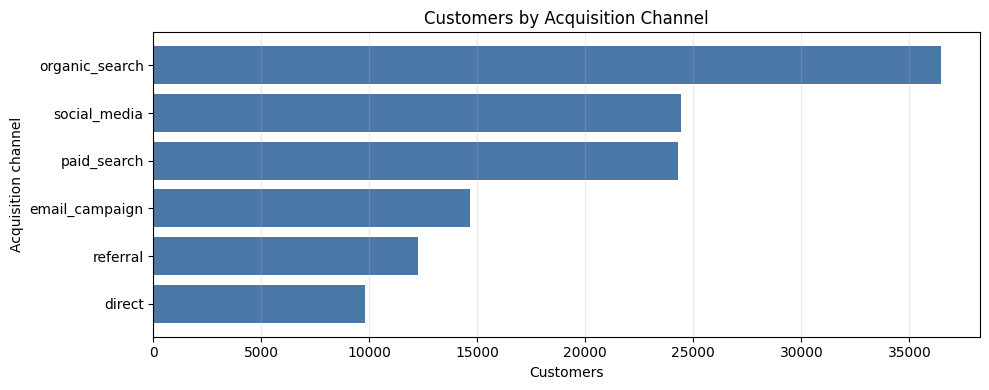

In [6]:
if not analysis_ready:
    print("WARNING: Skipping customers by channel because the customer-order dataset is unavailable.")
else:
    customers_channel_base = customers[[customer_id_customers_col, channel_col]].copy()
    customers_channel_base["acquisition_channel"] = customers_channel_base[channel_col].astype("string").fillna("Unknown")
    customers_by_channel = (
        customers_channel_base.groupby("acquisition_channel", as_index=False)
        .agg(customers=(customer_id_customers_col, "nunique"))
        .sort_values("customers", ascending=False)
    )
    customers_by_channel["customer_share"] = customers_by_channel["customers"] / customers_by_channel["customers"].sum()
    top_customer_channels_text = ", ".join(
        f"{row.acquisition_channel} ({int(row.customers):,}, {row.customer_share:.1%})"
        for row in customers_by_channel.head(5).itertuples()
    )
    display(customers_by_channel)
    print("Largest acquisition channels:", top_customer_channels_text)
    print("Smallest acquisition channels:", ", ".join(customers_by_channel.tail(5)["acquisition_channel"].astype(str).tolist()))

    plot_df = customers_by_channel.head(TOP_N_CHANNELS).sort_values("customers", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["acquisition_channel"].astype(str), plot_df["customers"], color="#4C78A8")
    ax.set_title("Customers by Acquisition Channel")
    ax.set_xlabel("Customers")
    ax.set_ylabel("Acquisition channel")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Orders per customer by acquisition channel

Analyze repeat behavior by channel using average and median orders per customer, one-time customer share, and repeat customer ratio.

,acquisition_channel,total_customers,total_orders,average_orders_per_customer,median_orders_per_customer,one_time_customer_ratio,repeat_customer_ratio
2,organic_search,26950,194227,7.206939,4.0,0.246160,0.753840
5,social_media,18002,129498,7.193534,4.0,0.243251,0.756749
3,paid_search,17999,128953,7.164454,4.0,0.249792,0.750208
1,email_campaign,10886,77775,7.144498,4.0,0.252342,0.747658
4,referral,9072,64473,7.106812,4.0,0.248677,0.751323
0,direct,7337,52019,7.089955,4.0,0.251601,0.748399


Channels with highest average orders per customer: organic_search (7.21), social_media (7.19), paid_search (7.16), email_campaign (7.14), referral (7.11)


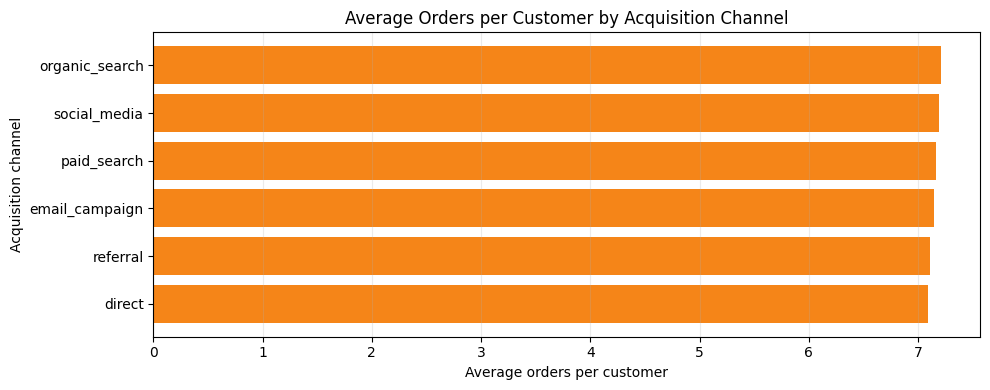

In [7]:
if not analysis_ready:
    print("WARNING: Skipping orders per customer analysis because the customer-order dataset is unavailable.")
else:
    customer_level = (
        customer_order_revenue.groupby(["customer_id", "acquisition_channel"], as_index=False)
        .agg(
            orders=("order_id", "nunique"),
            revenue=("revenue", "sum"),
            first_order_date=("order_date", "min"),
            acquisition_date=("customer_signup_date", "first"),
        )
    )
    customer_level["is_repeat_customer"] = customer_level["orders"] > 1
    customer_level["is_one_time_customer"] = customer_level["orders"] == 1

    orders_per_customer_by_channel = (
        customer_level.groupby("acquisition_channel", as_index=False)
        .agg(
            total_customers=("customer_id", "nunique"),
            total_orders=("orders", "sum"),
            average_orders_per_customer=("orders", "mean"),
            median_orders_per_customer=("orders", "median"),
            one_time_customer_ratio=("is_one_time_customer", "mean"),
            repeat_customer_ratio=("is_repeat_customer", "mean"),
        )
        .sort_values("average_orders_per_customer", ascending=False)
    )
    top_orders_per_customer_text = ", ".join(
        f"{row.acquisition_channel} ({row.average_orders_per_customer:.2f})"
        for row in orders_per_customer_by_channel.head(5).itertuples()
    )
    display(orders_per_customer_by_channel)
    print("Channels with highest average orders per customer:", top_orders_per_customer_text)

    plot_df = orders_per_customer_by_channel.head(TOP_N_CHANNELS).sort_values("average_orders_per_customer", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["acquisition_channel"].astype(str), plot_df["average_orders_per_customer"], color="#F58518")
    ax.set_title("Average Orders per Customer by Acquisition Channel")
    ax.set_xlabel("Average orders per customer")
    ax.set_ylabel("Acquisition channel")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Revenue by acquisition channel

Calculate total revenue, revenue share, revenue per customer, and revenue per order by channel.

,acquisition_channel,total_revenue,total_orders,average_revenue_per_order,median_revenue_per_order,customers,average_revenue_per_customer,median_revenue_per_customer,revenue_share
2,organic_search,4.937572e+09,194227,25421.655339,18324.60,26950,183212.313602,94868.400,0.300513
5,social_media,3.308171e+09,129498,25546.118230,18406.56,18002,183766.871376,95898.130,0.201344
3,paid_search,3.271723e+09,128953,25371.434229,18189.01,17999,181772.462810,93353.500,0.199125
1,email_campaign,1.967111e+09,77775,25292.330860,18089.10,10886,180700.995101,90585.245,0.119723
4,referral,1.634969e+09,64473,25358.978975,18287.20,9072,180221.500384,93818.965,0.099508
0,direct,1.310930e+09,52019,25200.993352,18168.26,7337,178673.909389,92365.750,0.079787


Channels with highest total revenue: organic_search (4,937,571,852, 30.1%), social_media (3,308,171,219, 20.1%), paid_search (3,271,722,558, 19.9%), email_campaign (1,967,111,033, 12.0%), referral (1,634,969,451, 10.0%)
Channels with highest average revenue per customer: social_media (183,767), organic_search (183,212), paid_search (181,772), email_campaign (180,701), referral (180,222)


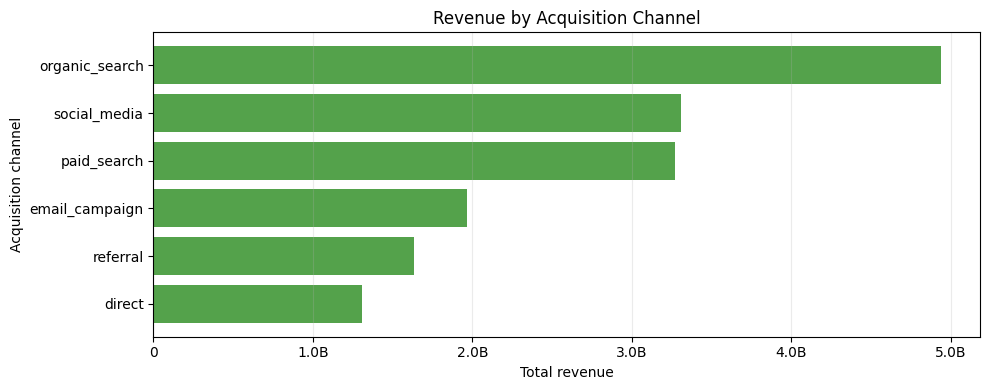

In [8]:
if not analysis_ready:
    print("WARNING: Skipping revenue by channel because the customer-order dataset is unavailable.")
else:
    order_level = customer_order_revenue.copy()
    revenue_by_customer = customer_level.copy()
    revenue_by_channel = (
        order_level.groupby("acquisition_channel", as_index=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_orders=("order_id", "nunique"),
            average_revenue_per_order=("revenue", "mean"),
            median_revenue_per_order=("revenue", "median"),
        )
    ).merge(
        revenue_by_customer.groupby("acquisition_channel", as_index=False).agg(
            customers=("customer_id", "nunique"),
            average_revenue_per_customer=("revenue", "mean"),
            median_revenue_per_customer=("revenue", "median"),
        ),
        on="acquisition_channel",
        how="left",
    )
    revenue_by_channel["revenue_share"] = revenue_by_channel["total_revenue"] / revenue_by_channel["total_revenue"].sum()
    revenue_by_channel = revenue_by_channel.sort_values("total_revenue", ascending=False)

    top_revenue_channels_text = ", ".join(
        f"{row.acquisition_channel} ({row.total_revenue:,.0f}, {row.revenue_share:.1%})"
        for row in revenue_by_channel.head(5).itertuples()
    )
    top_revenue_per_customer_text = ", ".join(
        f"{row.acquisition_channel} ({row.average_revenue_per_customer:,.0f})"
        for row in revenue_by_channel.sort_values("average_revenue_per_customer", ascending=False).head(5).itertuples()
    )
    display(revenue_by_channel)
    print("Channels with highest total revenue:", top_revenue_channels_text)
    print("Channels with highest average revenue per customer:", top_revenue_per_customer_text)

    plot_df = revenue_by_channel.head(TOP_N_CHANNELS).sort_values("total_revenue", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["acquisition_channel"].astype(str), plot_df["total_revenue"], color="#54A24B")
    ax.set_title("Revenue by Acquisition Channel")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Acquisition channel")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 9. Customer quality by acquisition channel

Create a channel quality summary. Quality depends on business objective: scale, retention, monetization, or total revenue.

,acquisition_channel,total_customers,total_orders,average_orders_per_customer,median_orders_per_customer,one_time_customer_ratio,repeat_customer_ratio,total_revenue,revenue_share,average_revenue_per_customer,median_revenue_per_customer,average_revenue_per_order,median_revenue_per_order,scale_rank_customers,retention_rank_repeat_ratio,monetization_rank_revenue_per_customer,revenue_rank_total,simple_quality_score
0,organic_search,26950,194227,7.206939,4.0,0.246160,0.753840,4.937572e+09,0.300513,183212.313602,94868.400,25421.655339,18324.60,1.0,2.0,2.0,1.0,6.0
1,social_media,18002,129498,7.193534,4.0,0.243251,0.756749,3.308171e+09,0.201344,183766.871376,95898.130,25546.118230,18406.56,2.0,1.0,1.0,2.0,6.0
2,paid_search,17999,128953,7.164454,4.0,0.249792,0.750208,3.271723e+09,0.199125,181772.462810,93353.500,25371.434229,18189.01,3.0,4.0,3.0,3.0,13.0
3,email_campaign,10886,77775,7.144498,4.0,0.252342,0.747658,1.967111e+09,0.119723,180700.995101,90585.245,25292.330860,18089.10,4.0,6.0,4.0,4.0,18.0
4,referral,9072,64473,7.106812,4.0,0.248677,0.751323,1.634969e+09,0.099508,180221.500384,93818.965,25358.978975,18287.20,5.0,3.0,5.0,5.0,18.0
5,direct,7337,52019,7.089955,4.0,0.251601,0.748399,1.310930e+09,0.079787,178673.909389,92365.750,25200.993352,18168.26,6.0,5.0,6.0,6.0,23.0


Quality is objective-dependent: scale favors many customers, retention favors repeat ratio, and monetization favors revenue per customer/order.


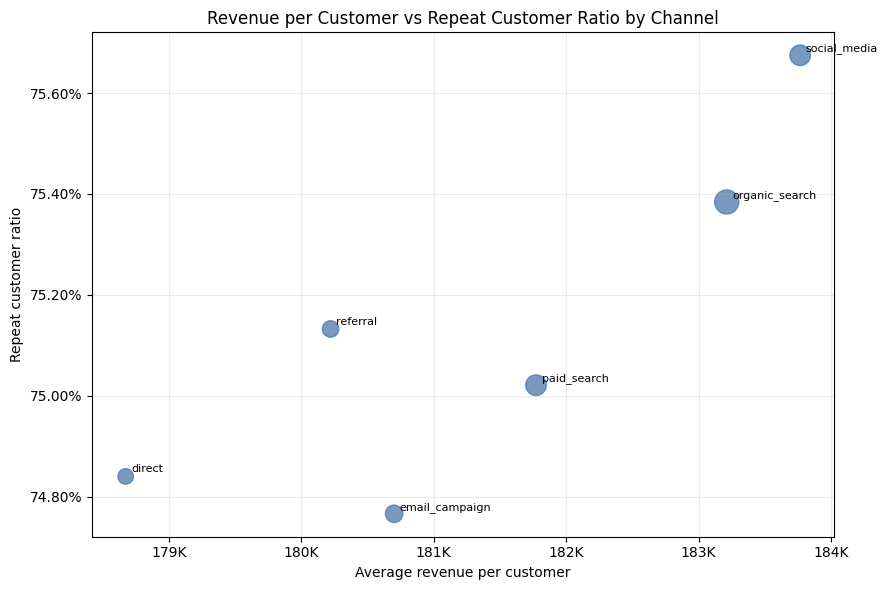

In [9]:
if not analysis_ready:
    print("WARNING: Skipping customer quality summary because the customer-order dataset is unavailable.")
else:
    quality_summary = orders_per_customer_by_channel.merge(
        revenue_by_channel[[
            "acquisition_channel", "total_revenue", "revenue_share", "average_revenue_per_customer",
            "median_revenue_per_customer", "average_revenue_per_order", "median_revenue_per_order",
        ]],
        on="acquisition_channel",
        how="left",
    )
    quality_summary["scale_rank_customers"] = quality_summary["total_customers"].rank(ascending=False, method="min")
    quality_summary["retention_rank_repeat_ratio"] = quality_summary["repeat_customer_ratio"].rank(ascending=False, method="min")
    quality_summary["monetization_rank_revenue_per_customer"] = quality_summary["average_revenue_per_customer"].rank(ascending=False, method="min")
    quality_summary["revenue_rank_total"] = quality_summary["total_revenue"].rank(ascending=False, method="min")
    quality_summary["simple_quality_score"] = (
        quality_summary["scale_rank_customers"]
        + quality_summary["retention_rank_repeat_ratio"]
        + quality_summary["monetization_rank_revenue_per_customer"]
        + quality_summary["revenue_rank_total"]
    )
    quality_summary = quality_summary.sort_values("simple_quality_score")
    display(quality_summary)
    print("Quality is objective-dependent: scale favors many customers, retention favors repeat ratio, and monetization favors revenue per customer/order.")

    scatter_df = quality_summary.dropna(subset=["average_revenue_per_customer", "repeat_customer_ratio"])
    fig, ax = plt.subplots(figsize=(9, 6))
    size_values = scatter_df["total_customers"].clip(lower=1)
    size_scaled = 60 + 240 * (size_values / size_values.max())
    ax.scatter(scatter_df["average_revenue_per_customer"], scatter_df["repeat_customer_ratio"], s=size_scaled, alpha=0.75, color="#4C78A8")
    for row in scatter_df.itertuples():
        ax.annotate(str(row.acquisition_channel), (row.average_revenue_per_customer, row.repeat_customer_ratio), fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.set_title("Revenue per Customer vs Repeat Customer Ratio by Channel")
    ax.set_xlabel("Average revenue per customer")
    ax.set_ylabel("Repeat customer ratio")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 10. Acquisition trend over time

Use customer signup date where available; otherwise use first observed order date as an acquisition-date proxy. New customers are aggregated by month and acquisition channel.

,acquisition_month,acquisition_channel,new_customers
0,2012-01-01,paid_search,1
1,2012-02-01,direct,2
2,2012-02-01,organic_search,5
3,2012-02-01,paid_search,6
4,2012-02-01,referral,1
5,2012-02-01,social_media,5
6,2012-03-01,email_campaign,1
7,2012-03-01,organic_search,9
8,2012-03-01,paid_search,2
9,2012-03-01,social_media,3


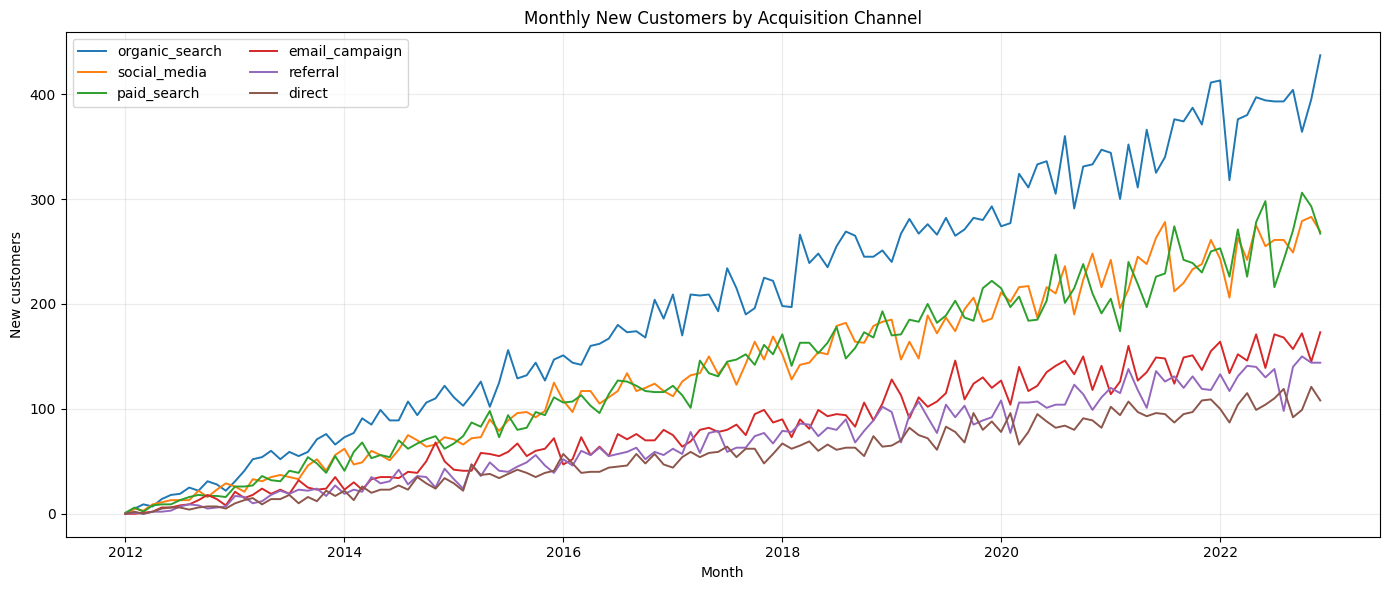

Acquisition channel mix changes over time: average absolute monthly share movement is 2.10%.


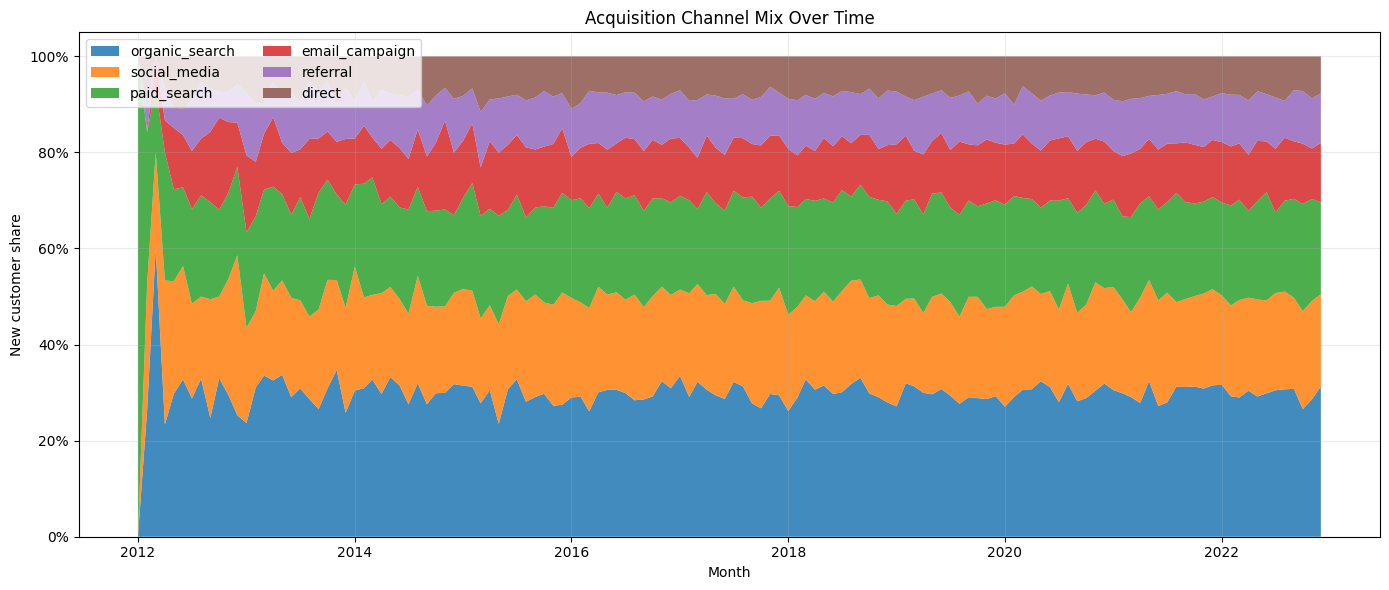

In [10]:
if not analysis_ready:
    print("WARNING: Skipping acquisition trend because the customer-order dataset is unavailable.")
else:
    acquisition_base = customer_level.copy()
    acquisition_base["acquisition_date_used"] = acquisition_base["acquisition_date"]
    acquisition_base.loc[acquisition_base["acquisition_date_used"].isna(), "acquisition_date_used"] = acquisition_base["first_order_date"]
    acquisition_base["used_first_order_proxy"] = acquisition_base["acquisition_date"].isna()
    if acquisition_base["used_first_order_proxy"].any() or used_signup_proxy:
        print("Some acquisition dates use first observed order date as a proxy.")
    acquisition_base = acquisition_base.dropna(subset=["acquisition_date_used"]).copy()
    acquisition_base["acquisition_month"] = acquisition_base["acquisition_date_used"].dt.to_period("M").dt.to_timestamp()

    monthly_acquisition = (
        acquisition_base.groupby(["acquisition_month", "acquisition_channel"], as_index=False)
        .agg(new_customers=("customer_id", "nunique"))
        .sort_values(["acquisition_month", "acquisition_channel"])
    )
    monthly_pivot = monthly_acquisition.pivot(index="acquisition_month", columns="acquisition_channel", values="new_customers").fillna(0)
    full_months = pd.date_range(monthly_pivot.index.min(), monthly_pivot.index.max(), freq="MS")
    monthly_pivot = monthly_pivot.reindex(full_months).fillna(0)
    monthly_pivot.index.name = "month"

    top_channels = customers_by_channel.head(min(TOP_N_CHANNELS, len(customers_by_channel)))["acquisition_channel"].tolist()
    display(monthly_acquisition.head(30))

    fig, ax = plt.subplots(figsize=(14, 6))
    for channel in top_channels:
        if channel in monthly_pivot.columns:
            ax.plot(monthly_pivot.index, monthly_pivot[channel], label=str(channel), linewidth=1.4)
    ax.set_title("Monthly New Customers by Acquisition Channel")
    ax.set_xlabel("Month")
    ax.set_ylabel("New customers")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    monthly_share = monthly_pivot.div(monthly_pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    top_share_channels = top_channels
    share_plot = monthly_share[top_share_channels].copy()
    other_channels = [col for col in monthly_share.columns if col not in top_share_channels]
    if other_channels:
        share_plot["Other"] = monthly_share[other_channels].sum(axis=1)
    avg_abs_share_change = share_plot.diff().abs().mean().mean()
    if pd.notna(avg_abs_share_change) and avg_abs_share_change >= 0.015:
        channel_mix_statement = f"Acquisition channel mix changes over time: average absolute monthly share movement is {avg_abs_share_change:.2%}."
    else:
        channel_mix_statement = f"Acquisition channel mix appears relatively stable: average absolute monthly share movement is {avg_abs_share_change:.2%}."
    print(channel_mix_statement)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.stackplot(share_plot.index, [share_plot[col] for col in share_plot.columns], labels=[str(col) for col in share_plot.columns], alpha=0.85)
    ax.set_title("Acquisition Channel Mix Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("New customer share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()

## 11. Repeat customer analysis

Define repeat customers as customers with more than one order and compare repeat behavior by channel. If enough data exists, repeat behavior is also summarized over time.

,acquisition_channel,customers,repeat_customers,repeat_customer_ratio,average_orders_per_customer
5,social_media,18002,13623,0.756749,7.193534
2,organic_search,26950,20316,0.753840,7.206939
4,referral,9072,6816,0.751323,7.106812
3,paid_search,17999,13503,0.750208,7.164454
0,direct,7337,5491,0.748399,7.089955
1,email_campaign,10886,8139,0.747658,7.144498


Channels with strongest repeat customer ratio: social_media (75.7%), organic_search (75.4%), referral (75.1%), paid_search (75.0%), direct (74.8%)


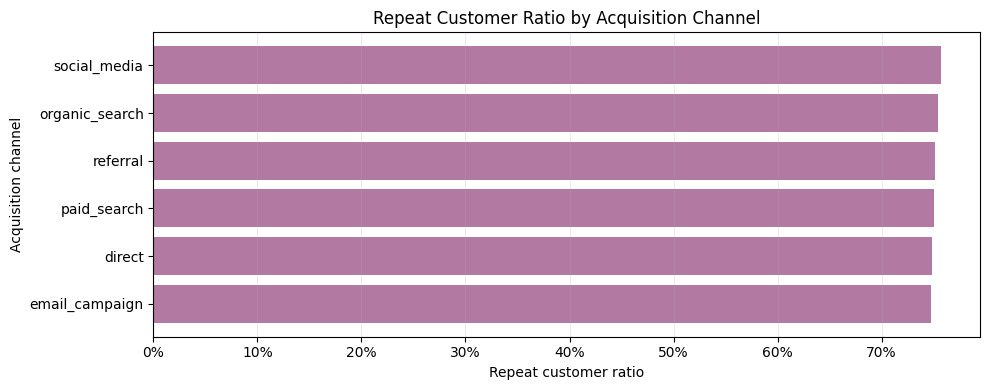

Repeat ratio by first-order month and channel preview


,first_order_month,acquisition_channel,customers,repeat_ratio
0,2012-07-01,direct,393,0.969466
1,2012-07-01,email_campaign,619,0.949919
2,2012-07-01,organic_search,1436,0.961699
3,2012-07-01,paid_search,933,0.966774
4,2012-07-01,referral,521,0.971209
5,2012-07-01,social_media,981,0.954128
6,2012-08-01,direct,417,0.947242
7,2012-08-01,email_campaign,602,0.960133
8,2012-08-01,organic_search,1518,0.953887
9,2012-08-01,paid_search,1034,0.944874


In [11]:
if not analysis_ready:
    print("WARNING: Skipping repeat customer analysis because the customer-order dataset is unavailable.")
else:
    repeat_by_channel = (
        customer_level.groupby("acquisition_channel", as_index=False)
        .agg(
            customers=("customer_id", "nunique"),
            repeat_customers=("is_repeat_customer", "sum"),
            repeat_customer_ratio=("is_repeat_customer", "mean"),
            average_orders_per_customer=("orders", "mean"),
        )
        .sort_values("repeat_customer_ratio", ascending=False)
    )
    top_repeat_channels_text = ", ".join(
        f"{row.acquisition_channel} ({row.repeat_customer_ratio:.1%})"
        for row in repeat_by_channel.head(5).itertuples()
    )
    display(repeat_by_channel)
    print("Channels with strongest repeat customer ratio:", top_repeat_channels_text)

    plot_df = repeat_by_channel.head(TOP_N_CHANNELS).sort_values("repeat_customer_ratio", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["acquisition_channel"].astype(str), plot_df["repeat_customer_ratio"], color="#B279A2")
    ax.set_title("Repeat Customer Ratio by Acquisition Channel")
    ax.set_xlabel("Repeat customer ratio")
    ax.set_ylabel("Acquisition channel")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    repeat_time = customer_level.dropna(subset=["first_order_date"]).copy()
    repeat_time["first_order_month"] = repeat_time["first_order_date"].dt.to_period("M").dt.to_timestamp()
    repeat_time_summary = (
        repeat_time.groupby(["first_order_month", "acquisition_channel"], as_index=False)
        .agg(customers=("customer_id", "nunique"), repeat_ratio=("is_repeat_customer", "mean"))
    )
    print("Repeat ratio by first-order month and channel preview")
    display(repeat_time_summary.head(30))

## 12. Leakage-safe acquisition forecast feature preview

Create daily acquisition features using only historical information. Daily acquisition counts and channel mix are shifted before rolling or feature calculations.

In [12]:
def entropy_from_shares(row):
    values = row.dropna()
    values = values[values > 0]
    if values.empty:
        return np.nan
    return float(-(values * np.log(values)).sum())


if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because the customer-order dataset is unavailable.")
else:
    daily_revenue = customer_order_revenue.groupby("order_date")["revenue"].sum()
    full_days = pd.date_range(customer_order_revenue["order_date"].min(), customer_order_revenue["order_date"].max(), freq="D")
    daily_revenue = daily_revenue.reindex(full_days).fillna(0)

    acquisition_daily = acquisition_base.groupby(["acquisition_date_used", "acquisition_channel"])["customer_id"].nunique().reset_index(name="new_customers")
    channel_pivot = acquisition_daily.pivot(index="acquisition_date_used", columns="acquisition_channel", values="new_customers").reindex(full_days).fillna(0)
    channel_pivot.index.name = "date"
    daily_new_customers = channel_pivot.sum(axis=1)

    daily_repeat_orders = customer_order_revenue.merge(customer_level[["customer_id", "is_repeat_customer"]], on="customer_id", how="left")
    repeat_ratio_by_day = daily_repeat_orders.groupby("order_date")["is_repeat_customer"].mean().reindex(full_days)

    shifted_new_customers = daily_new_customers.shift(1)
    shifted_repeat_ratio = repeat_ratio_by_day.shift(1)
    shifted_channel = channel_pivot.shift(1)
    rolling_channel_30 = shifted_channel.rolling(window=30, min_periods=7).sum()
    rolling_channel_total = rolling_channel_30.sum(axis=1)
    rolling_channel_share = rolling_channel_30.div(rolling_channel_total.replace(0, np.nan), axis=0)

    feature_df = pd.DataFrame({
        "date": full_days,
        "total_revenue": daily_revenue.values,
        "daily_new_customers_lag": shifted_new_customers.values,
        "new_customers_roll_mean_7": shifted_new_customers.rolling(window=7, min_periods=3).mean().values,
        "new_customers_roll_mean_30": shifted_new_customers.rolling(window=30, min_periods=7).mean().values,
        "repeat_customer_ratio_lag": shifted_repeat_ratio.values,
        "repeat_customer_ratio_roll_mean_30": shifted_repeat_ratio.rolling(window=30, min_periods=7).mean().values,
        "channel_mix_lag": rolling_channel_share.idxmax(axis=1).astype("string").values,
        "top_channel_share_lag": rolling_channel_share.max(axis=1).values,
        "channel_concentration_lag": (rolling_channel_share.fillna(0) ** 2).sum(axis=1).values,
    })
    feature_preview = feature_df.dropna(subset=["daily_new_customers_lag", "top_channel_share_lag"], how="all").head(20)
    if feature_preview.empty:
        feature_preview = feature_df.head(20)
    display(feature_preview)
    print("Leakage-safe construction: acquisition counts, repeat ratios, and channel mix are shifted before rolling or forecast-feature calculations.")
    print(forecast_warning)
    print("Recommended acquisition forecast features:", ", ".join(recommended_acquisition_features))

,date,total_revenue,daily_new_customers_lag,new_customers_roll_mean_7,new_customers_roll_mean_30,repeat_customer_ratio_lag,repeat_customer_ratio_roll_mean_30,channel_mix_lag,top_channel_share_lag,channel_concentration_lag
1,2012-07-05,2751773.45,2.0,NaN,NaN,0.938272,NaN,<NA>,NaN,0.000000
2,2012-07-06,3054029.42,4.0,NaN,NaN,0.958763,NaN,<NA>,NaN,0.000000
3,2012-07-07,2667930.94,0.0,2.000000,NaN,0.978495,NaN,<NA>,NaN,0.000000
4,2012-07-08,2360851.90,3.0,2.250000,NaN,0.931507,NaN,<NA>,NaN,0.000000
5,2012-07-09,3548386.46,2.0,2.200000,NaN,0.943182,NaN,<NA>,NaN,0.000000
6,2012-07-10,5234938.62,2.0,2.166667,NaN,0.963504,NaN,<NA>,NaN,0.000000
7,2012-07-11,5582884.78,2.0,2.142857,2.142857,0.972678,0.955200,organic_search,0.333333,0.217778
8,2012-07-12,5734632.02,1.0,2.000000,2.000000,0.968326,0.956841,organic_search,0.375000,0.234375
9,2012-07-13,5309511.71,1.0,1.571429,1.888889,0.967480,0.958023,organic_search,0.411765,0.252595
10,2012-07-14,3820831.41,0.0,1.571429,1.700000,0.985075,0.960728,organic_search,0.411765,0.252595


Leakage-safe construction: acquisition counts, repeat ratios, and channel mix are shifted before rolling or forecast-feature calculations.
Future customers and future channel mix must not be used directly for forecasting unless separately forecasted.
Recommended acquisition forecast features: daily_new_customers_lag, new_customers_roll_mean_7, new_customers_roll_mean_30, repeat_customer_ratio_lag, repeat_customer_ratio_roll_mean_30, channel_mix_lag, top_channel_share_lag, channel_concentration_lag


## 13. Key observations and warnings

Summarize acquisition scale, revenue, monetization, repeat behavior, channel-mix change, marketing implications, and leakage-safe forecast feature recommendations.

In [13]:
if analysis_ready:
    if not quality_summary.empty:
        best_overall = quality_summary.head(3)["acquisition_channel"].astype(str).tolist()
        marketing_implications = (
            "Scale channels can support volume goals; high revenue-per-customer channels may deserve monetization-focused budget tests; "
            "high repeat-ratio channels may deserve retention analysis. Validate with controlled marketing or backtests before reallocating budget."
        )
    else:
        best_overall = []
        marketing_implications = "Not enough channel quality data to summarize marketing implications."

    print("Insight summary")
    print(f"- Acquisition channels with the most customers: {top_customer_channels_text}")
    print(f"- Channels with highest total revenue: {top_revenue_channels_text}")
    print(f"- Channels with highest revenue per customer: {top_revenue_per_customer_text}")
    print(f"- Channels with highest average orders per customer: {top_orders_per_customer_text}")
    print(f"- Channels with strongest repeat customer ratio: {top_repeat_channels_text}")
    print(f"- Acquisition channel mix over time: {channel_mix_statement}")
    print(f"- Marketing implications by channel: {marketing_implications}")
    print(f"- Recommended leakage-safe acquisition forecast features: {', '.join(recommended_acquisition_features)}")
    print(f"- Forecasting warning: {forecast_warning}")
else:
    print("Insight summary")
    print("- Customer acquisition analysis could not be completed because required joined data was not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Acquisition channels with the most customers: organic_search (36,450, 29.9%), social_media (24,448, 20.1%), paid_search (24,285, 19.9%), email_campaign (14,674, 12.0%), referral (12,270, 10.1%)
- Channels with highest total revenue: organic_search (4,937,571,852, 30.1%), social_media (3,308,171,219, 20.1%), paid_search (3,271,722,558, 19.9%), email_campaign (1,967,111,033, 12.0%), referral (1,634,969,451, 10.0%)
- Channels with highest revenue per customer: social_media (183,767), organic_search (183,212), paid_search (181,772), email_campaign (180,701), referral (180,222)
- Channels with highest average orders per customer: organic_search (7.21), social_media (7.19), paid_search (7.16), email_campaign (7.14), referral (7.11)
- Channels with strongest repeat customer ratio: social_media (75.7%), organic_search (75.4%), referral (75.1%), paid_search (75.0%), direct (74.8%)
- Acquisition channel mix over time: Acquisition channel mix changes over time: average absolute 